In [24]:
%load_ext autoreload
%autoreload 2

import matplotlib.pyplot as plt
import numpy as np
from IPython.display import display, clear_output
from functools import partial

import torch
import torch.nn.functional as F
from torch.utils.data import DataLoader
from torch.utils.tensorboard import SummaryWriter
from tqdm import tqdm

from src.config import Config
from src.episode import Episode
from src.episode_dataset import EpisodeRLDataset
from src.rl_data_record import RLDataRecord
from src.train_stage import TrainStage
from src.policy_factory import PolicyMode, PolicyFactory
from src.reward_model import RewardModel
from src.grpo_trainer import GRPOTrainer
from src.policy_model_utils import load_checkpoint, inference_and_plot_policy_v2, get_model_size
from src.utils import get_color, normalize_min_max, to_device_collate, top_k_sampling
from src.episode_batch_repeat_sampler import EpisodeBatchRepeatSampler

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


# Setup
---

In [25]:
config = Config()
reward_model = RewardModel(config=config)
test_policy = PolicyFactory.create(
    policy_mode=PolicyMode.TRANSFORMER_WITH_LATE_POSITION_FUSION, config=config
)

# Datasets

train_dataset = EpisodeRLDataset(config=config, split="TRAIN")
print(f"train_dataset : {len(train_dataset)}")

test_dataset = EpisodeRLDataset(config=config, split="TEST")
print(f"test_dataset : {len(test_dataset)}")

eval_dataset = EpisodeRLDataset(config=config, split="EVAL")
print(f"eval_dataset : {len(eval_dataset)}")


# DataLoaders
def get_data_loader(
    dataset: EpisodeRLDataset, batch_size: int, group_size: int, repeats: int
):
    batch_repeat_sampler = EpisodeBatchRepeatSampler(
        dataset=dataset,
        batch_size=batch_size,
        group_size=group_size,
        repeats=repeats,
    )
    # print(
    #     f"batch_repeat_sampler: {len(batch_repeat_sampler)},  {list(batch_repeat_sampler)}"
    # )
    # print(
    #     f"batch ids: {[e.episode_id for e in dataset.get_episods(batch_episode_indices=list(batch_repeat_sampler))]}"
    # )

    to_device_collate_configurable = partial(to_device_collate, config.device)
    dataloader = DataLoader(
        dataset,
        batch_size=batch_size * group_size,
        sampler=batch_repeat_sampler,
        collate_fn=to_device_collate_configurable,
    )
    print(f"data loader: {dataset.split}, {len(dataloader)}")
    return dataloader


train_dataloader = get_data_loader(
    dataset=train_dataset,
    batch_size=config.train_batch_size,
    group_size=config.episode_group_size,
    repeats=config.episode_steps,
)

test_dataloader = get_data_loader(
    dataset=test_dataset,
    batch_size=config.test_batch_size,
    group_size=config.episode_group_size,
    repeats=config.episode_steps,
)

eval_dataloader = get_data_loader(
    dataset=eval_dataset,
    batch_size=config.eval_batch_size,
    group_size=config.episode_group_size,
    repeats=config.episode_steps,
)

train_dataset : 2400
test_dataset : 1600
eval_dataset : 8000
data loader: TRAIN, 40
data loader: TEST, 100
data loader: EVAL, 100


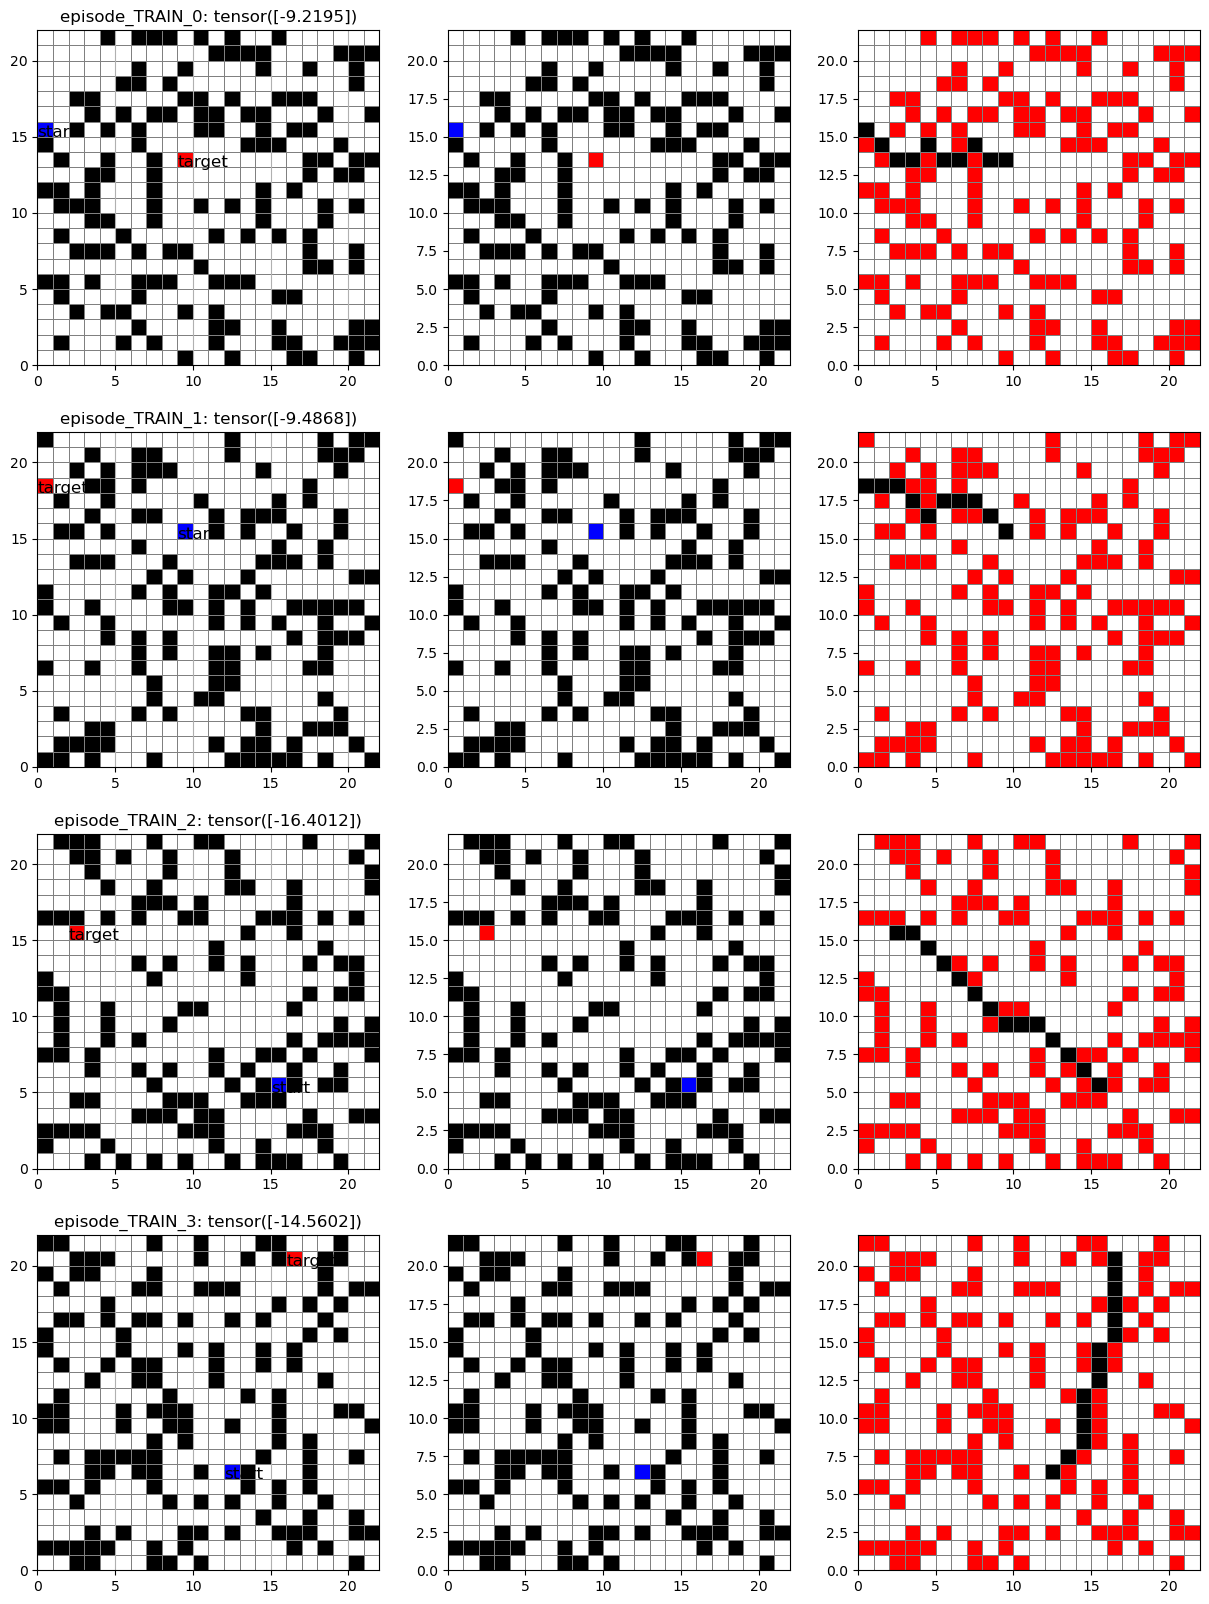

In [3]:
episode_samples = 4
fig, axes = plt.subplots(
    nrows=episode_samples, ncols=3, squeeze=False, figsize=(15, 20)
)

for eidx in range(episode_samples):
    es = train_dataset.get_episode(eidx * config.episode_group_size)
    es.viz(ax=axes[eidx][0], reward_model=reward_model)

    # Viz fov
    fov = es.fov(center_pos=es.agent.start_state.position())
    # print(f"fov: {fov.size()}, {fov}")
    # print(f"fov: {fov}")
    es.viz_fov(ax=axes[eidx][1])
    es.viz_optimal_path(ax=axes[eidx][2])

    es = train_dataset.get_episode(eidx)

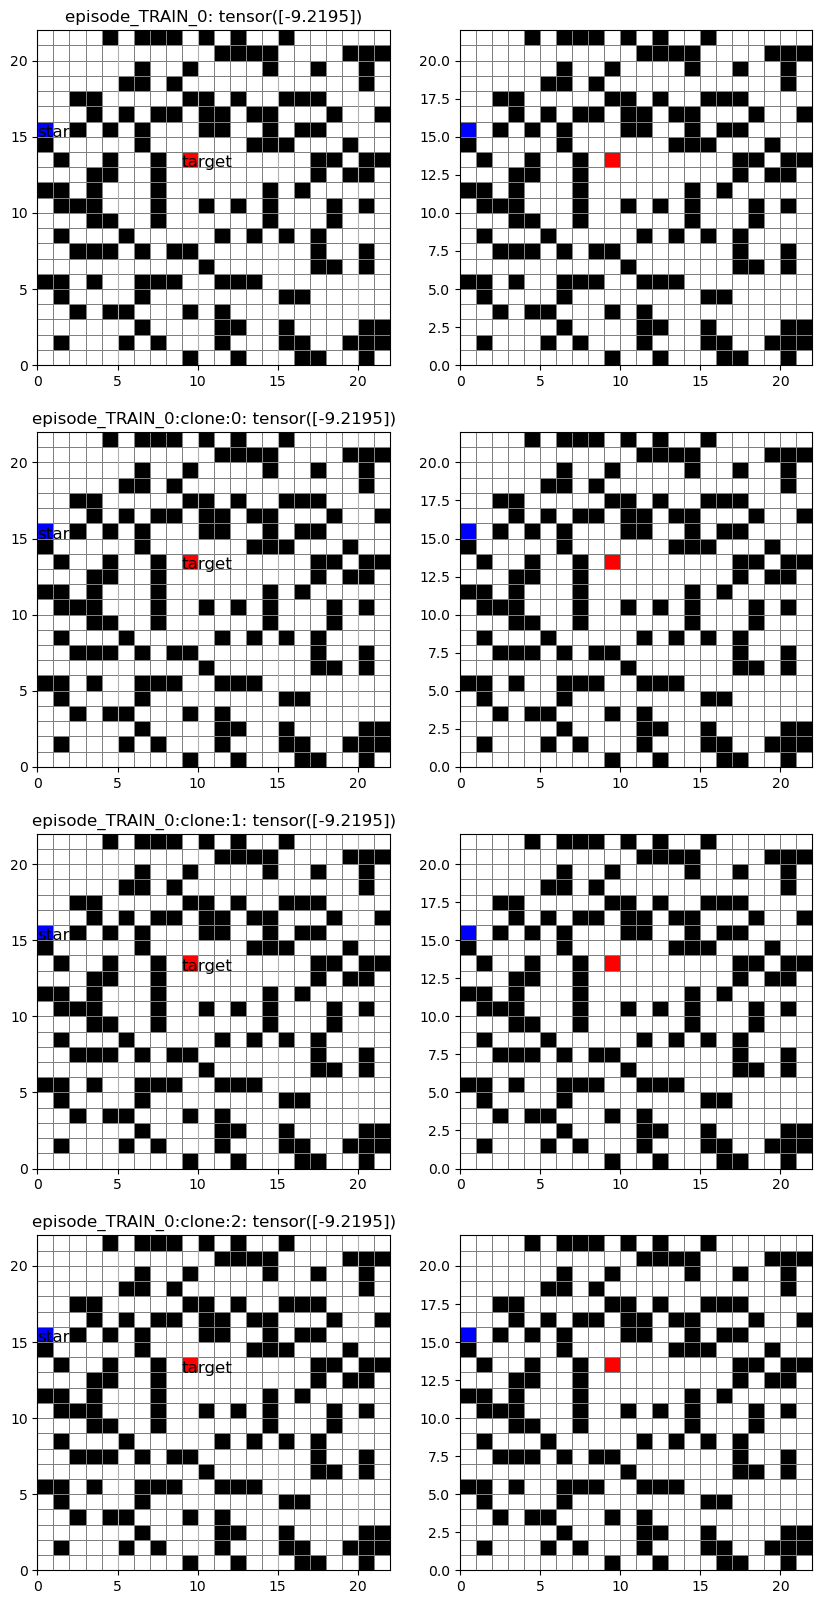

In [4]:
episode_samples = 4
fig, axes = plt.subplots(nrows=episode_samples, ncols=2, figsize=(10, 20))

for eidx in range(episode_samples):
    es = train_dataset.get_episode(eidx)
    es.optimal_path()

    es.viz(ax=axes[eidx][0], reward_model=reward_model)

    # Viz fov
    fov = es.fov(center_pos=es.agent.start_state.position())
    # print(f"fov: {fov.size()}, {fov}")
    # print(f"fov: {fov}")
    es.viz_fov(ax=axes[eidx][1])
plt.show()

# Training Loop
---

In [5]:
# policy = PolicyFactory.create(
#     policy_mode=PolicyMode.TRANSFORMER_WITH_LATE_POSITION_FUSION, config=config
# ).to(config.device)
# pretrain_model_path = "/Users/chengbai/ml/cheng_git/rf_agent/rf_model_policy_PRE_TRAIN_20250701160706_1.pt"
pretrain_model_path = "/Users/chengbai/ml/cheng_git/rf_agent/rf_model_policy_FINE_TUNE_STAGE_1_20250703153848_1.pt"
policy, optimizer, lr_scheduler = load_checkpoint(
    checkpoint_path=pretrain_model_path,
    config=config,
    policy_mode=PolicyMode.TRANSFORMER_WITH_LATE_POSITION_FUSION,
)
policy.to(config.device)

get_model_size(model=policy)

reward_model = RewardModel(config=config)
trainer = GRPOTrainer(config=config, policy=policy, reward_model=reward_model)

Total number of parameters: 597189
Model size (bytes): 2388756
Model size (MB): 2.278095245361328


TEST:  19%|█▉        | 19/100 [00:05<00:23,  3.49it/s]

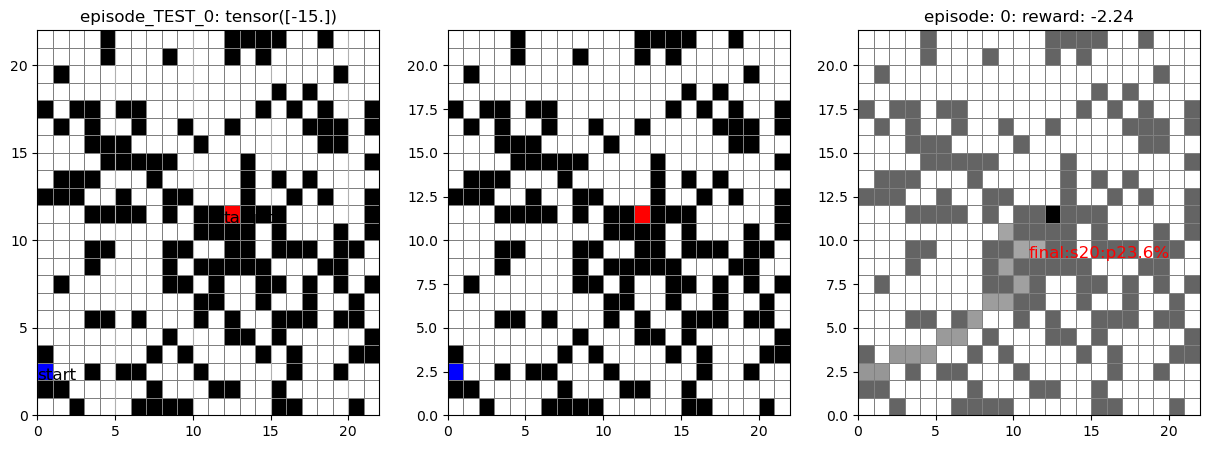

TEST:  39%|███▉      | 39/100 [00:11<00:17,  3.50it/s, split=TEST, batch_idx=19, is_episode_step_done=1, target_episodes=['episode_TEST_0', 'episode_TEST_0:clone:0', 'episode_TEST_0:clone:1', 'episode_TEST_0:clone:2', 'episode_TEST_0:clone:3', 'episode_TEST_0:clone:4', 'episode_TEST_0:clone:5', 'episode_TEST_0:clone:6', 'episode_TEST_1', 'episode_TEST_1:clone:0', 'episode_TEST_1:clone:1', 'episode_TEST_1:clone:2', 'episode_TEST_1:clone:3', 'episode_TEST_1:clone:4', 'episode_TEST_1:clone:5', 'episode_TEST_1:clone:6', 'episode_TEST_2', 'episode_TEST_2:clone:0', 'episode_TEST_2:clone:1', 'episode_TEST_2:clone:2', 'episode_TEST_2:clone:3', 'episode_TEST_2:clone:4', 'episode_TEST_2:clone:5', 'episode_TEST_2:clone:6', 'episode_TEST_3', 'episode_TEST_3:clone:0', 'episode_TEST_3:clone:1', 'episode_TEST_3:clone:2', 'episode_TEST_3:clone:3', 'episode_TEST_3:clone:4', 'episode_TEST_3:clone:5', 'episode_TEST_3:clone:6', 'episode_TEST_4', 'episode_TEST_4:clone:0', 'episode_TEST_4:clone:1', 'episode

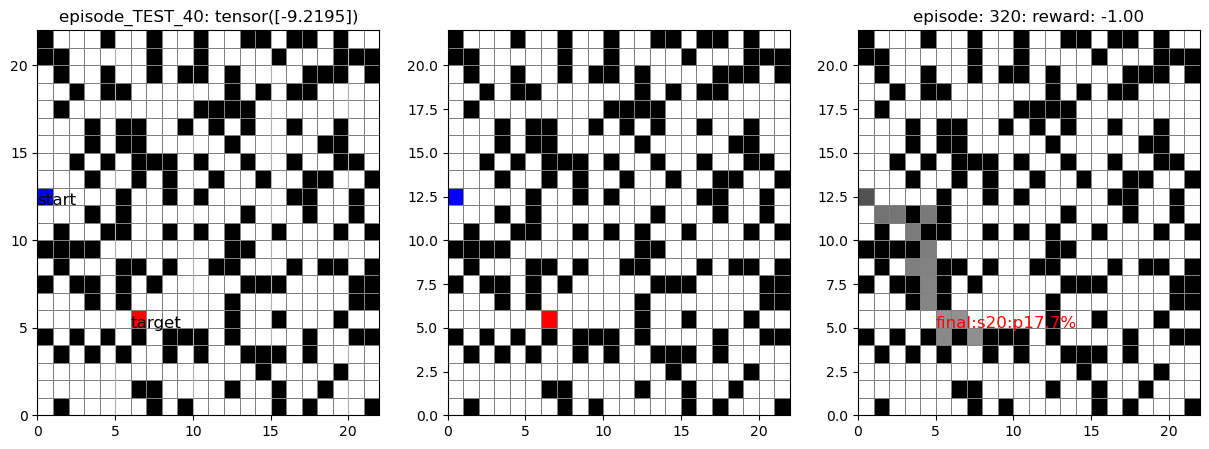

TEST:  59%|█████▉    | 59/100 [00:17<00:11,  3.49it/s, split=TEST, batch_idx=39, is_episode_step_done=1, target_episodes=['episode_TEST_40', 'episode_TEST_40:clone:0', 'episode_TEST_40:clone:1', 'episode_TEST_40:clone:2', 'episode_TEST_40:clone:3', 'episode_TEST_40:clone:4', 'episode_TEST_40:clone:5', 'episode_TEST_40:clone:6', 'episode_TEST_41', 'episode_TEST_41:clone:0', 'episode_TEST_41:clone:1', 'episode_TEST_41:clone:2', 'episode_TEST_41:clone:3', 'episode_TEST_41:clone:4', 'episode_TEST_41:clone:5', 'episode_TEST_41:clone:6', 'episode_TEST_42', 'episode_TEST_42:clone:0', 'episode_TEST_42:clone:1', 'episode_TEST_42:clone:2', 'episode_TEST_42:clone:3', 'episode_TEST_42:clone:4', 'episode_TEST_42:clone:5', 'episode_TEST_42:clone:6', 'episode_TEST_43', 'episode_TEST_43:clone:0', 'episode_TEST_43:clone:1', 'episode_TEST_43:clone:2', 'episode_TEST_43:clone:3', 'episode_TEST_43:clone:4', 'episode_TEST_43:clone:5', 'episode_TEST_43:clone:6', 'episode_TEST_44', 'episode_TEST_44:clone:0', 

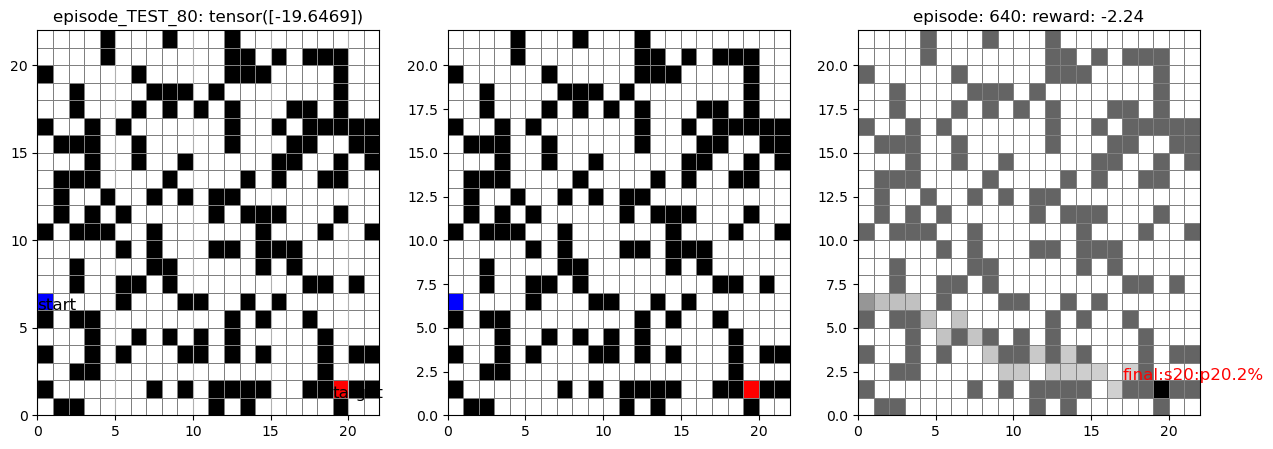

TEST:  79%|███████▉  | 79/100 [00:23<00:06,  3.48it/s, split=TEST, batch_idx=59, is_episode_step_done=1, target_episodes=['episode_TEST_80', 'episode_TEST_80:clone:0', 'episode_TEST_80:clone:1', 'episode_TEST_80:clone:2', 'episode_TEST_80:clone:3', 'episode_TEST_80:clone:4', 'episode_TEST_80:clone:5', 'episode_TEST_80:clone:6', 'episode_TEST_81', 'episode_TEST_81:clone:0', 'episode_TEST_81:clone:1', 'episode_TEST_81:clone:2', 'episode_TEST_81:clone:3', 'episode_TEST_81:clone:4', 'episode_TEST_81:clone:5', 'episode_TEST_81:clone:6', 'episode_TEST_82', 'episode_TEST_82:clone:0', 'episode_TEST_82:clone:1', 'episode_TEST_82:clone:2', 'episode_TEST_82:clone:3', 'episode_TEST_82:clone:4', 'episode_TEST_82:clone:5', 'episode_TEST_82:clone:6', 'episode_TEST_83', 'episode_TEST_83:clone:0', 'episode_TEST_83:clone:1', 'episode_TEST_83:clone:2', 'episode_TEST_83:clone:3', 'episode_TEST_83:clone:4', 'episode_TEST_83:clone:5', 'episode_TEST_83:clone:6', 'episode_TEST_84', 'episode_TEST_84:clone:0', 

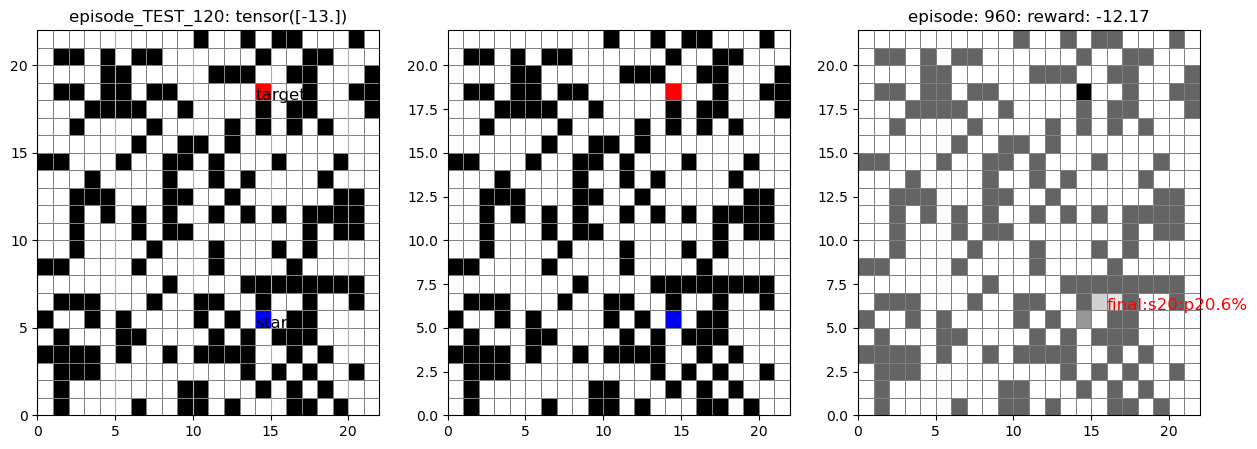

TEST:  99%|█████████▉| 99/100 [00:29<00:00,  3.49it/s, split=TEST, batch_idx=79, is_episode_step_done=1, target_episodes=['episode_TEST_120', 'episode_TEST_120:clone:0', 'episode_TEST_120:clone:1', 'episode_TEST_120:clone:2', 'episode_TEST_120:clone:3', 'episode_TEST_120:clone:4', 'episode_TEST_120:clone:5', 'episode_TEST_120:clone:6', 'episode_TEST_121', 'episode_TEST_121:clone:0', 'episode_TEST_121:clone:1', 'episode_TEST_121:clone:2', 'episode_TEST_121:clone:3', 'episode_TEST_121:clone:4', 'episode_TEST_121:clone:5', 'episode_TEST_121:clone:6', 'episode_TEST_122', 'episode_TEST_122:clone:0', 'episode_TEST_122:clone:1', 'episode_TEST_122:clone:2', 'episode_TEST_122:clone:3', 'episode_TEST_122:clone:4', 'episode_TEST_122:clone:5', 'episode_TEST_122:clone:6', 'episode_TEST_123', 'episode_TEST_123:clone:0', 'episode_TEST_123:clone:1', 'episode_TEST_123:clone:2', 'episode_TEST_123:clone:3', 'episode_TEST_123:clone:4', 'episode_TEST_123:clone:5', 'episode_TEST_123:clone:6', 'episode_TEST_

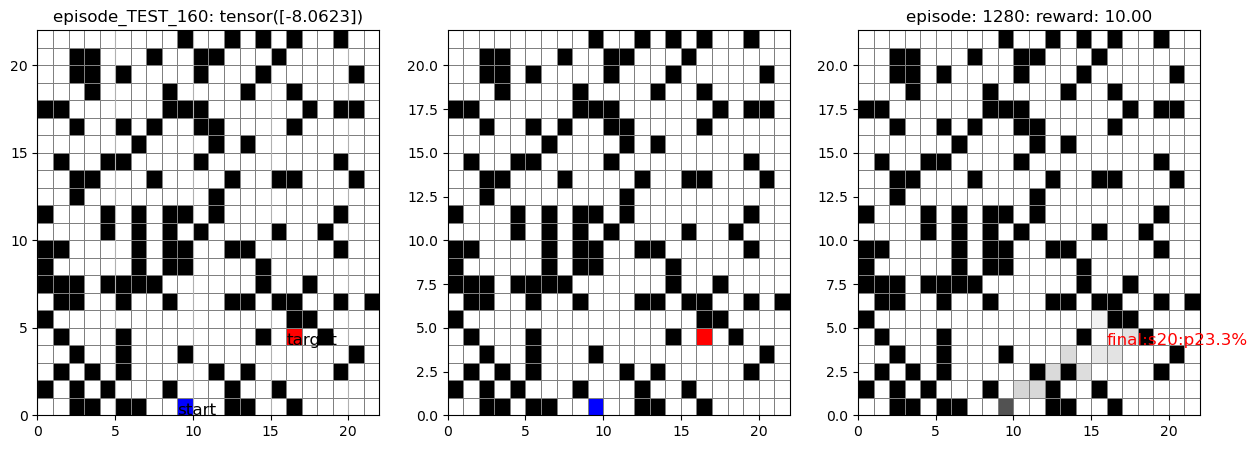

TEST: 100%|██████████| 100/100 [00:30<00:00,  3.28it/s, split=TEST, batch_idx=99, is_episode_step_done=1, target_episodes=['episode_TEST_160', 'episode_TEST_160:clone:0', 'episode_TEST_160:clone:1', 'episode_TEST_160:clone:2', 'episode_TEST_160:clone:3', 'episode_TEST_160:clone:4', 'episode_TEST_160:clone:5', 'episode_TEST_160:clone:6', 'episode_TEST_161', 'episode_TEST_161:clone:0', 'episode_TEST_161:clone:1', 'episode_TEST_161:clone:2', 'episode_TEST_161:clone:3', 'episode_TEST_161:clone:4', 'episode_TEST_161:clone:5', 'episode_TEST_161:clone:6', 'episode_TEST_162', 'episode_TEST_162:clone:0', 'episode_TEST_162:clone:1', 'episode_TEST_162:clone:2', 'episode_TEST_162:clone:3', 'episode_TEST_162:clone:4', 'episode_TEST_162:clone:5', 'episode_TEST_162:clone:6', 'episode_TEST_163', 'episode_TEST_163:clone:0', 'episode_TEST_163:clone:1', 'episode_TEST_163:clone:2', 'episode_TEST_163:clone:3', 'episode_TEST_163:clone:4', 'episode_TEST_163:clone:5', 'episode_TEST_163:clone:6', 'episode_TEST

In [6]:
inference_and_plot_policy_v2(
    config=config,
    dataset=test_dataset,
    dataloader=test_dataloader,
    policy=policy,
    reward_model=reward_model,
    top_k=2,
)

In [7]:
# plt.ioff()
trainer.run(
    train_dataset=train_dataset,
    eval_dataset=eval_dataset,
    train_stage=TrainStage.FINE_TUNE_STAGE_1,
    debug=False,
)

# plt.ion()

train_dataloader: 6000, eval_dataloader: 100
run_id: 20250704144110


Epoch 1:   0%|          | 0/6000 [00:00<?, ?it/s]/Users/chengbai/ml/cheng_git/rf_agent/src/policy/transformer_model_policy.py:236: TracerWarning: Converting a tensor to a Python boolean might cause the trace to be incorrect. We can't record the data flow of Python values, so this value will be treated as a constant in the future. This means that the trace might not generalize to other inputs!
  batch_fov.size(0)
/Users/chengbai/ml/cheng_git/rf_agent/src/policy/transformer_model_policy.py:67: TracerWarning: torch.tensor results are registered as constants in the trace. You can safely ignore this warning if you use this function to create tensors out of constant variables that would be the same every time you call this function. In any other case, this might cause the trace to be incorrect.
  torch.tensor(T, dtype=torch.float, device=self.config.device)
/Users/chengbai/ml/cheng_git/rf_agent/src/policy/transformer_model_policy.py:67: UserWarning: To copy construct from a tensor, it is rec

Save checkpoint to: rf_model_policy_FINE_TUNE_STAGE_1_20250704144110_0.pt


Epoch 2: 100%|██████████| 6000/6000 [10:45:25<00:00,  6.45s/it, split=TRAIN, step=600, batch_idx=5999, is_episode_step_done=1]    


Save checkpoint to: rf_model_policy_FINE_TUNE_STAGE_1_20250704144110_1.pt


Epoch 2: 100%|██████████| 100/100 [02:26<00:00,  1.47s/it, split=EVAL, step=10, batch_idx=99, is_episode_step_done=1]


# Evaluate the Model
----

TEST:  19%|█▉        | 19/100 [00:05<00:23,  3.39it/s]

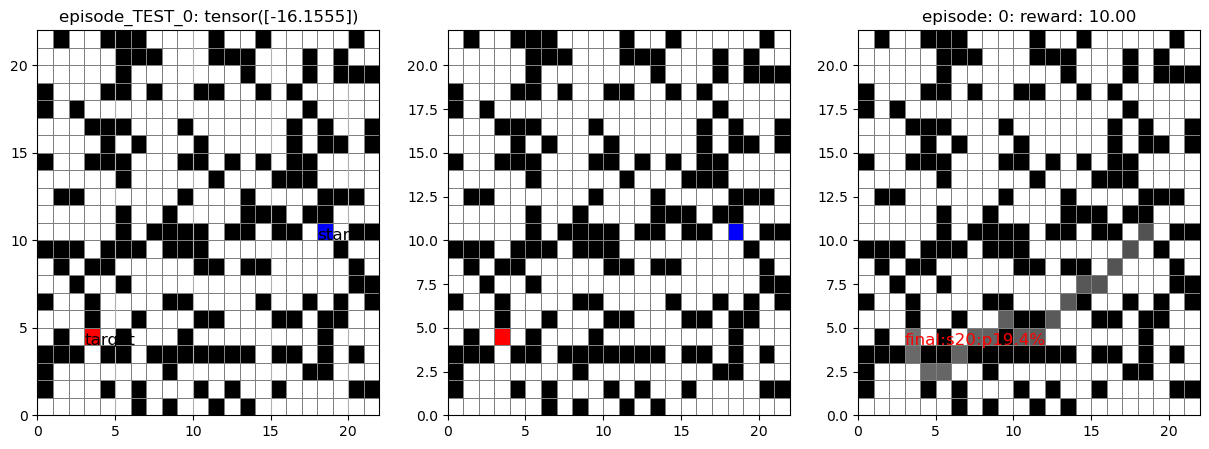

TEST:  39%|███▉      | 39/100 [00:11<00:17,  3.44it/s, split=TEST, batch_idx=19, is_episode_step_done=1, target_episodes=['episode_TEST_0', 'episode_TEST_0:clone:0', 'episode_TEST_0:clone:1', 'episode_TEST_0:clone:2', 'episode_TEST_0:clone:3', 'episode_TEST_0:clone:4', 'episode_TEST_0:clone:5', 'episode_TEST_0:clone:6', 'episode_TEST_1', 'episode_TEST_1:clone:0', 'episode_TEST_1:clone:1', 'episode_TEST_1:clone:2', 'episode_TEST_1:clone:3', 'episode_TEST_1:clone:4', 'episode_TEST_1:clone:5', 'episode_TEST_1:clone:6', 'episode_TEST_2', 'episode_TEST_2:clone:0', 'episode_TEST_2:clone:1', 'episode_TEST_2:clone:2', 'episode_TEST_2:clone:3', 'episode_TEST_2:clone:4', 'episode_TEST_2:clone:5', 'episode_TEST_2:clone:6', 'episode_TEST_3', 'episode_TEST_3:clone:0', 'episode_TEST_3:clone:1', 'episode_TEST_3:clone:2', 'episode_TEST_3:clone:3', 'episode_TEST_3:clone:4', 'episode_TEST_3:clone:5', 'episode_TEST_3:clone:6', 'episode_TEST_4', 'episode_TEST_4:clone:0', 'episode_TEST_4:clone:1', 'episode

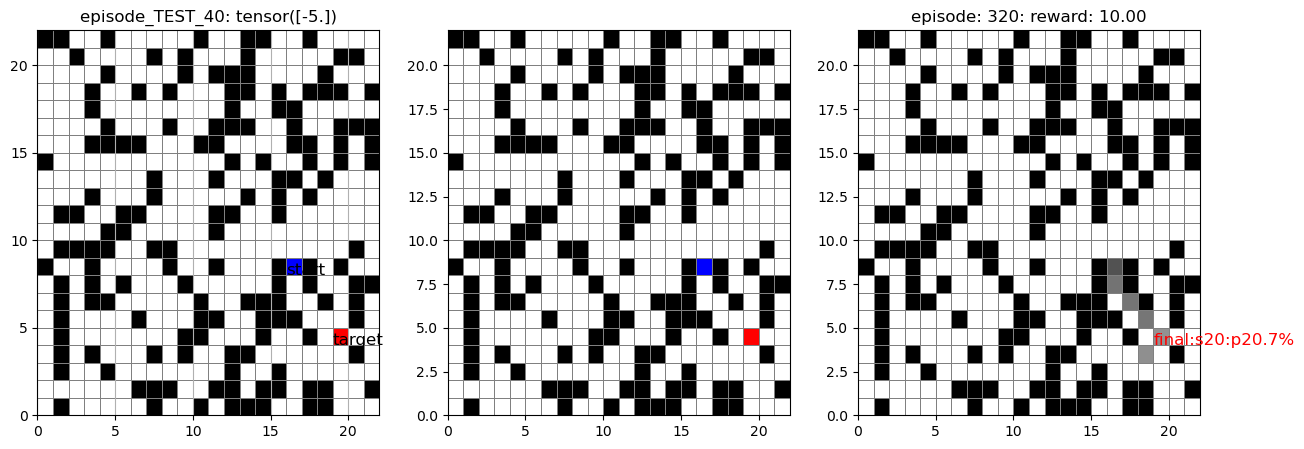

TEST:  59%|█████▉    | 59/100 [00:17<00:11,  3.49it/s, split=TEST, batch_idx=39, is_episode_step_done=1, target_episodes=['episode_TEST_40', 'episode_TEST_40:clone:0', 'episode_TEST_40:clone:1', 'episode_TEST_40:clone:2', 'episode_TEST_40:clone:3', 'episode_TEST_40:clone:4', 'episode_TEST_40:clone:5', 'episode_TEST_40:clone:6', 'episode_TEST_41', 'episode_TEST_41:clone:0', 'episode_TEST_41:clone:1', 'episode_TEST_41:clone:2', 'episode_TEST_41:clone:3', 'episode_TEST_41:clone:4', 'episode_TEST_41:clone:5', 'episode_TEST_41:clone:6', 'episode_TEST_42', 'episode_TEST_42:clone:0', 'episode_TEST_42:clone:1', 'episode_TEST_42:clone:2', 'episode_TEST_42:clone:3', 'episode_TEST_42:clone:4', 'episode_TEST_42:clone:5', 'episode_TEST_42:clone:6', 'episode_TEST_43', 'episode_TEST_43:clone:0', 'episode_TEST_43:clone:1', 'episode_TEST_43:clone:2', 'episode_TEST_43:clone:3', 'episode_TEST_43:clone:4', 'episode_TEST_43:clone:5', 'episode_TEST_43:clone:6', 'episode_TEST_44', 'episode_TEST_44:clone:0', 

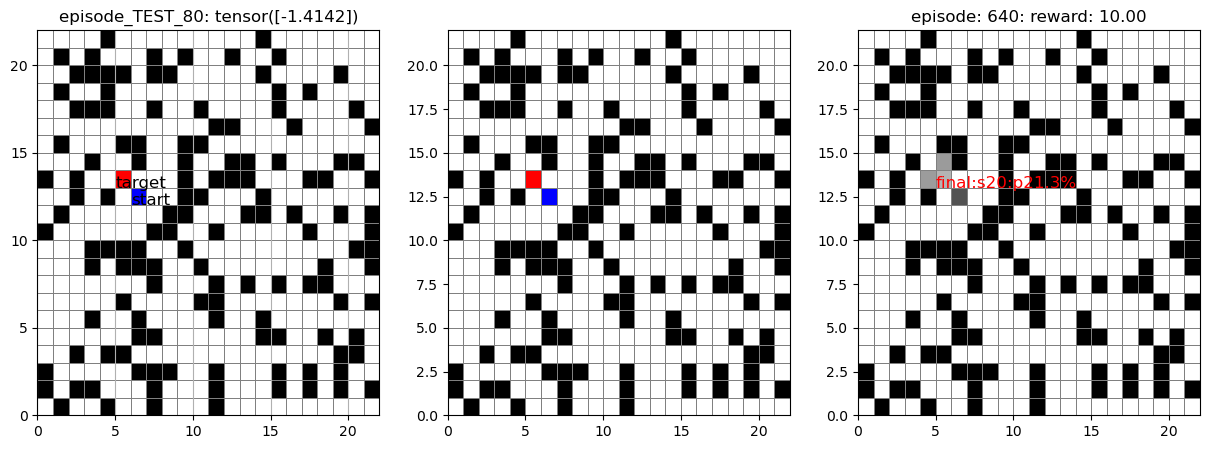

TEST:  79%|███████▉  | 79/100 [00:23<00:05,  3.58it/s, split=TEST, batch_idx=59, is_episode_step_done=1, target_episodes=['episode_TEST_80', 'episode_TEST_80:clone:0', 'episode_TEST_80:clone:1', 'episode_TEST_80:clone:2', 'episode_TEST_80:clone:3', 'episode_TEST_80:clone:4', 'episode_TEST_80:clone:5', 'episode_TEST_80:clone:6', 'episode_TEST_81', 'episode_TEST_81:clone:0', 'episode_TEST_81:clone:1', 'episode_TEST_81:clone:2', 'episode_TEST_81:clone:3', 'episode_TEST_81:clone:4', 'episode_TEST_81:clone:5', 'episode_TEST_81:clone:6', 'episode_TEST_82', 'episode_TEST_82:clone:0', 'episode_TEST_82:clone:1', 'episode_TEST_82:clone:2', 'episode_TEST_82:clone:3', 'episode_TEST_82:clone:4', 'episode_TEST_82:clone:5', 'episode_TEST_82:clone:6', 'episode_TEST_83', 'episode_TEST_83:clone:0', 'episode_TEST_83:clone:1', 'episode_TEST_83:clone:2', 'episode_TEST_83:clone:3', 'episode_TEST_83:clone:4', 'episode_TEST_83:clone:5', 'episode_TEST_83:clone:6', 'episode_TEST_84', 'episode_TEST_84:clone:0', 

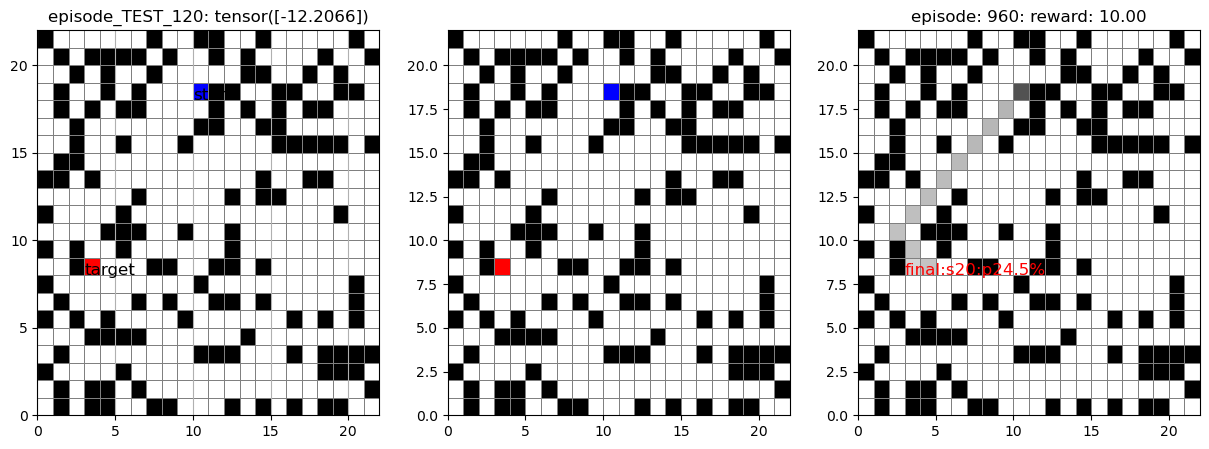

TEST:  99%|█████████▉| 99/100 [00:29<00:00,  3.55it/s, split=TEST, batch_idx=79, is_episode_step_done=1, target_episodes=['episode_TEST_120', 'episode_TEST_120:clone:0', 'episode_TEST_120:clone:1', 'episode_TEST_120:clone:2', 'episode_TEST_120:clone:3', 'episode_TEST_120:clone:4', 'episode_TEST_120:clone:5', 'episode_TEST_120:clone:6', 'episode_TEST_121', 'episode_TEST_121:clone:0', 'episode_TEST_121:clone:1', 'episode_TEST_121:clone:2', 'episode_TEST_121:clone:3', 'episode_TEST_121:clone:4', 'episode_TEST_121:clone:5', 'episode_TEST_121:clone:6', 'episode_TEST_122', 'episode_TEST_122:clone:0', 'episode_TEST_122:clone:1', 'episode_TEST_122:clone:2', 'episode_TEST_122:clone:3', 'episode_TEST_122:clone:4', 'episode_TEST_122:clone:5', 'episode_TEST_122:clone:6', 'episode_TEST_123', 'episode_TEST_123:clone:0', 'episode_TEST_123:clone:1', 'episode_TEST_123:clone:2', 'episode_TEST_123:clone:3', 'episode_TEST_123:clone:4', 'episode_TEST_123:clone:5', 'episode_TEST_123:clone:6', 'episode_TEST_

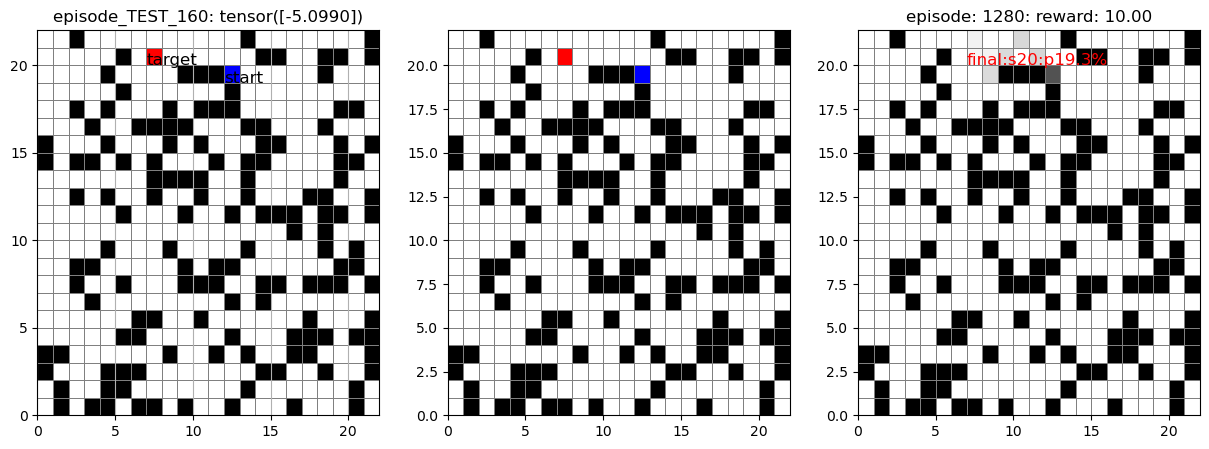

TEST: 100%|██████████| 100/100 [00:30<00:00,  3.33it/s, split=TEST, batch_idx=99, is_episode_step_done=1, target_episodes=['episode_TEST_160', 'episode_TEST_160:clone:0', 'episode_TEST_160:clone:1', 'episode_TEST_160:clone:2', 'episode_TEST_160:clone:3', 'episode_TEST_160:clone:4', 'episode_TEST_160:clone:5', 'episode_TEST_160:clone:6', 'episode_TEST_161', 'episode_TEST_161:clone:0', 'episode_TEST_161:clone:1', 'episode_TEST_161:clone:2', 'episode_TEST_161:clone:3', 'episode_TEST_161:clone:4', 'episode_TEST_161:clone:5', 'episode_TEST_161:clone:6', 'episode_TEST_162', 'episode_TEST_162:clone:0', 'episode_TEST_162:clone:1', 'episode_TEST_162:clone:2', 'episode_TEST_162:clone:3', 'episode_TEST_162:clone:4', 'episode_TEST_162:clone:5', 'episode_TEST_162:clone:6', 'episode_TEST_163', 'episode_TEST_163:clone:0', 'episode_TEST_163:clone:1', 'episode_TEST_163:clone:2', 'episode_TEST_163:clone:3', 'episode_TEST_163:clone:4', 'episode_TEST_163:clone:5', 'episode_TEST_163:clone:6', 'episode_TEST

In [26]:
inference_and_plot_policy_v2(
    config=config,
    dataset=test_dataset,
    dataloader=test_dataloader,
    policy=policy,
    reward_model=reward_model,
    top_k=1,
)

TEST:  19%|█▉        | 19/100 [00:05<00:23,  3.49it/s]

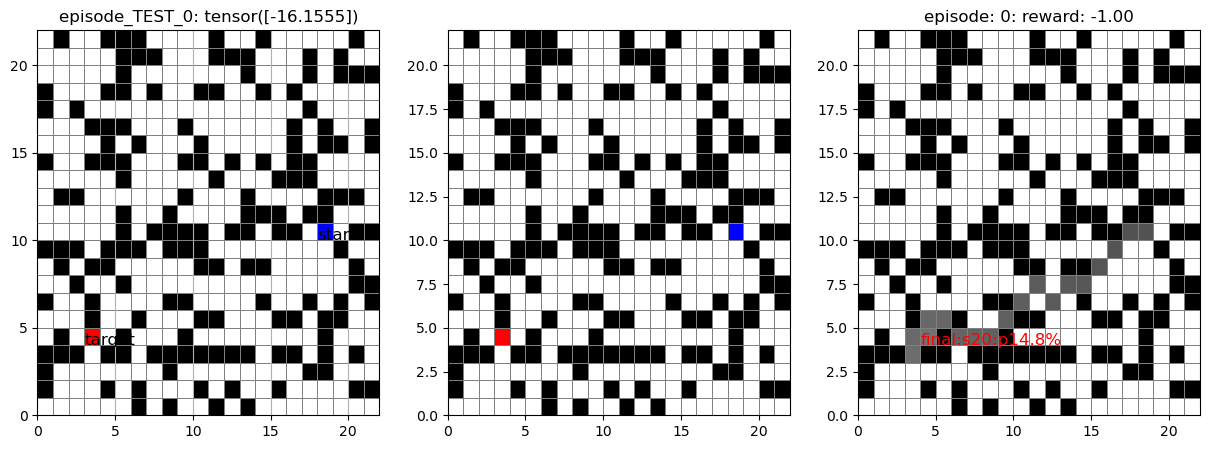

TEST:  39%|███▉      | 39/100 [00:11<00:17,  3.53it/s, split=TEST, batch_idx=19, is_episode_step_done=1, target_episodes=['episode_TEST_0', 'episode_TEST_0:clone:0', 'episode_TEST_0:clone:1', 'episode_TEST_0:clone:2', 'episode_TEST_0:clone:3', 'episode_TEST_0:clone:4', 'episode_TEST_0:clone:5', 'episode_TEST_0:clone:6', 'episode_TEST_1', 'episode_TEST_1:clone:0', 'episode_TEST_1:clone:1', 'episode_TEST_1:clone:2', 'episode_TEST_1:clone:3', 'episode_TEST_1:clone:4', 'episode_TEST_1:clone:5', 'episode_TEST_1:clone:6', 'episode_TEST_2', 'episode_TEST_2:clone:0', 'episode_TEST_2:clone:1', 'episode_TEST_2:clone:2', 'episode_TEST_2:clone:3', 'episode_TEST_2:clone:4', 'episode_TEST_2:clone:5', 'episode_TEST_2:clone:6', 'episode_TEST_3', 'episode_TEST_3:clone:0', 'episode_TEST_3:clone:1', 'episode_TEST_3:clone:2', 'episode_TEST_3:clone:3', 'episode_TEST_3:clone:4', 'episode_TEST_3:clone:5', 'episode_TEST_3:clone:6', 'episode_TEST_4', 'episode_TEST_4:clone:0', 'episode_TEST_4:clone:1', 'episode

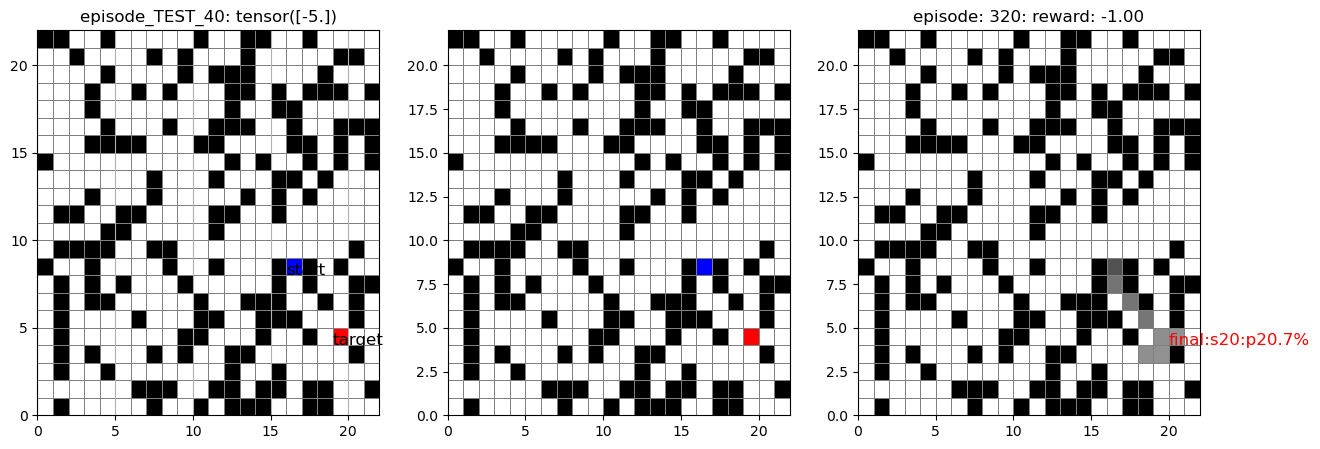

TEST:  59%|█████▉    | 59/100 [00:17<00:11,  3.45it/s, split=TEST, batch_idx=39, is_episode_step_done=1, target_episodes=['episode_TEST_40', 'episode_TEST_40:clone:0', 'episode_TEST_40:clone:1', 'episode_TEST_40:clone:2', 'episode_TEST_40:clone:3', 'episode_TEST_40:clone:4', 'episode_TEST_40:clone:5', 'episode_TEST_40:clone:6', 'episode_TEST_41', 'episode_TEST_41:clone:0', 'episode_TEST_41:clone:1', 'episode_TEST_41:clone:2', 'episode_TEST_41:clone:3', 'episode_TEST_41:clone:4', 'episode_TEST_41:clone:5', 'episode_TEST_41:clone:6', 'episode_TEST_42', 'episode_TEST_42:clone:0', 'episode_TEST_42:clone:1', 'episode_TEST_42:clone:2', 'episode_TEST_42:clone:3', 'episode_TEST_42:clone:4', 'episode_TEST_42:clone:5', 'episode_TEST_42:clone:6', 'episode_TEST_43', 'episode_TEST_43:clone:0', 'episode_TEST_43:clone:1', 'episode_TEST_43:clone:2', 'episode_TEST_43:clone:3', 'episode_TEST_43:clone:4', 'episode_TEST_43:clone:5', 'episode_TEST_43:clone:6', 'episode_TEST_44', 'episode_TEST_44:clone:0', 

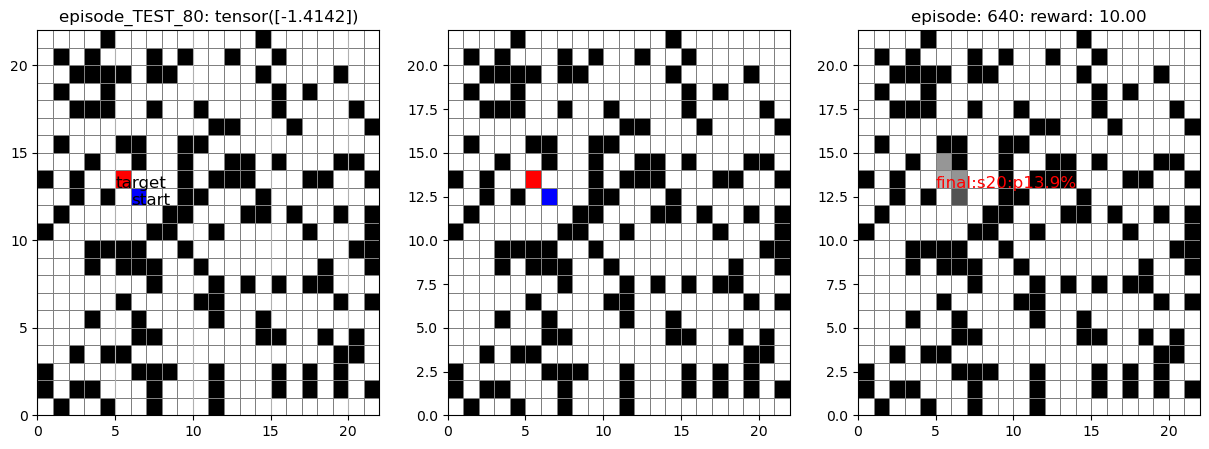

TEST:  79%|███████▉  | 79/100 [00:23<00:06,  3.49it/s, split=TEST, batch_idx=59, is_episode_step_done=1, target_episodes=['episode_TEST_80', 'episode_TEST_80:clone:0', 'episode_TEST_80:clone:1', 'episode_TEST_80:clone:2', 'episode_TEST_80:clone:3', 'episode_TEST_80:clone:4', 'episode_TEST_80:clone:5', 'episode_TEST_80:clone:6', 'episode_TEST_81', 'episode_TEST_81:clone:0', 'episode_TEST_81:clone:1', 'episode_TEST_81:clone:2', 'episode_TEST_81:clone:3', 'episode_TEST_81:clone:4', 'episode_TEST_81:clone:5', 'episode_TEST_81:clone:6', 'episode_TEST_82', 'episode_TEST_82:clone:0', 'episode_TEST_82:clone:1', 'episode_TEST_82:clone:2', 'episode_TEST_82:clone:3', 'episode_TEST_82:clone:4', 'episode_TEST_82:clone:5', 'episode_TEST_82:clone:6', 'episode_TEST_83', 'episode_TEST_83:clone:0', 'episode_TEST_83:clone:1', 'episode_TEST_83:clone:2', 'episode_TEST_83:clone:3', 'episode_TEST_83:clone:4', 'episode_TEST_83:clone:5', 'episode_TEST_83:clone:6', 'episode_TEST_84', 'episode_TEST_84:clone:0', 

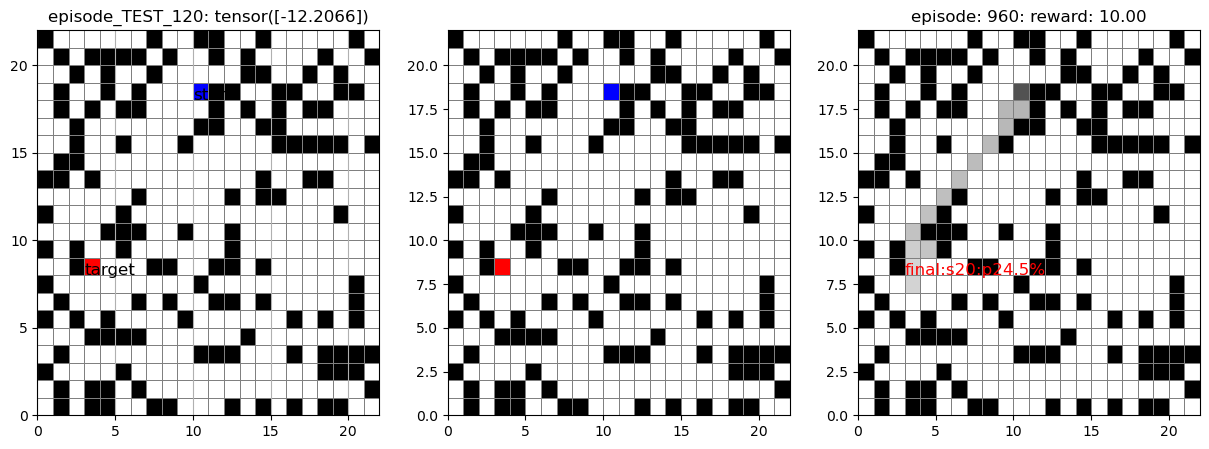

TEST:  99%|█████████▉| 99/100 [00:29<00:00,  3.38it/s, split=TEST, batch_idx=79, is_episode_step_done=1, target_episodes=['episode_TEST_120', 'episode_TEST_120:clone:0', 'episode_TEST_120:clone:1', 'episode_TEST_120:clone:2', 'episode_TEST_120:clone:3', 'episode_TEST_120:clone:4', 'episode_TEST_120:clone:5', 'episode_TEST_120:clone:6', 'episode_TEST_121', 'episode_TEST_121:clone:0', 'episode_TEST_121:clone:1', 'episode_TEST_121:clone:2', 'episode_TEST_121:clone:3', 'episode_TEST_121:clone:4', 'episode_TEST_121:clone:5', 'episode_TEST_121:clone:6', 'episode_TEST_122', 'episode_TEST_122:clone:0', 'episode_TEST_122:clone:1', 'episode_TEST_122:clone:2', 'episode_TEST_122:clone:3', 'episode_TEST_122:clone:4', 'episode_TEST_122:clone:5', 'episode_TEST_122:clone:6', 'episode_TEST_123', 'episode_TEST_123:clone:0', 'episode_TEST_123:clone:1', 'episode_TEST_123:clone:2', 'episode_TEST_123:clone:3', 'episode_TEST_123:clone:4', 'episode_TEST_123:clone:5', 'episode_TEST_123:clone:6', 'episode_TEST_

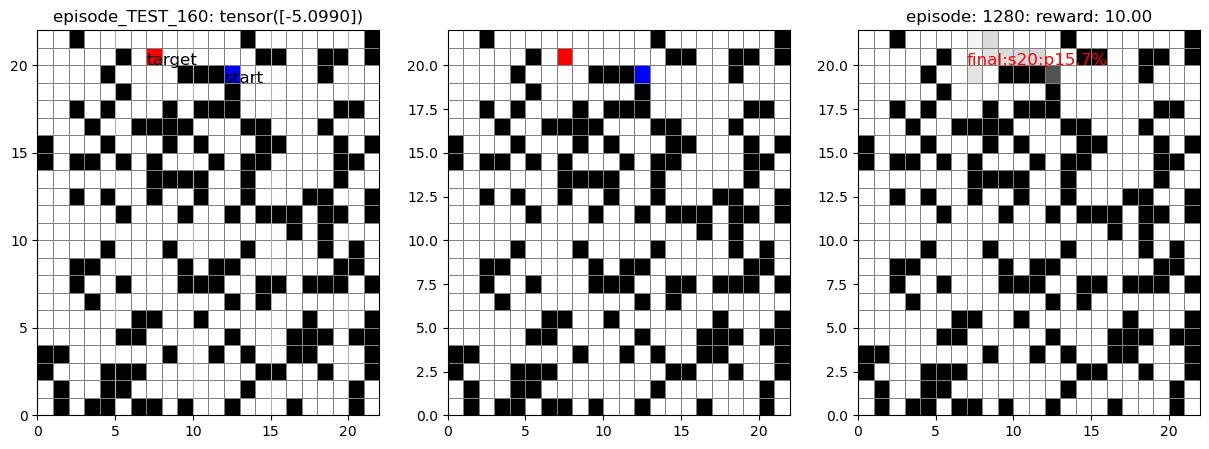

TEST: 100%|██████████| 100/100 [00:30<00:00,  3.29it/s, split=TEST, batch_idx=99, is_episode_step_done=1, target_episodes=['episode_TEST_160', 'episode_TEST_160:clone:0', 'episode_TEST_160:clone:1', 'episode_TEST_160:clone:2', 'episode_TEST_160:clone:3', 'episode_TEST_160:clone:4', 'episode_TEST_160:clone:5', 'episode_TEST_160:clone:6', 'episode_TEST_161', 'episode_TEST_161:clone:0', 'episode_TEST_161:clone:1', 'episode_TEST_161:clone:2', 'episode_TEST_161:clone:3', 'episode_TEST_161:clone:4', 'episode_TEST_161:clone:5', 'episode_TEST_161:clone:6', 'episode_TEST_162', 'episode_TEST_162:clone:0', 'episode_TEST_162:clone:1', 'episode_TEST_162:clone:2', 'episode_TEST_162:clone:3', 'episode_TEST_162:clone:4', 'episode_TEST_162:clone:5', 'episode_TEST_162:clone:6', 'episode_TEST_163', 'episode_TEST_163:clone:0', 'episode_TEST_163:clone:1', 'episode_TEST_163:clone:2', 'episode_TEST_163:clone:3', 'episode_TEST_163:clone:4', 'episode_TEST_163:clone:5', 'episode_TEST_163:clone:6', 'episode_TEST

In [27]:
inference_and_plot_policy_v2(
    config=config,
    dataset=test_dataset,
    dataloader=test_dataloader,
    policy=policy,
    reward_model=reward_model,
    top_k=2,
)

TEST:  19%|█▉        | 19/100 [00:05<00:23,  3.43it/s]

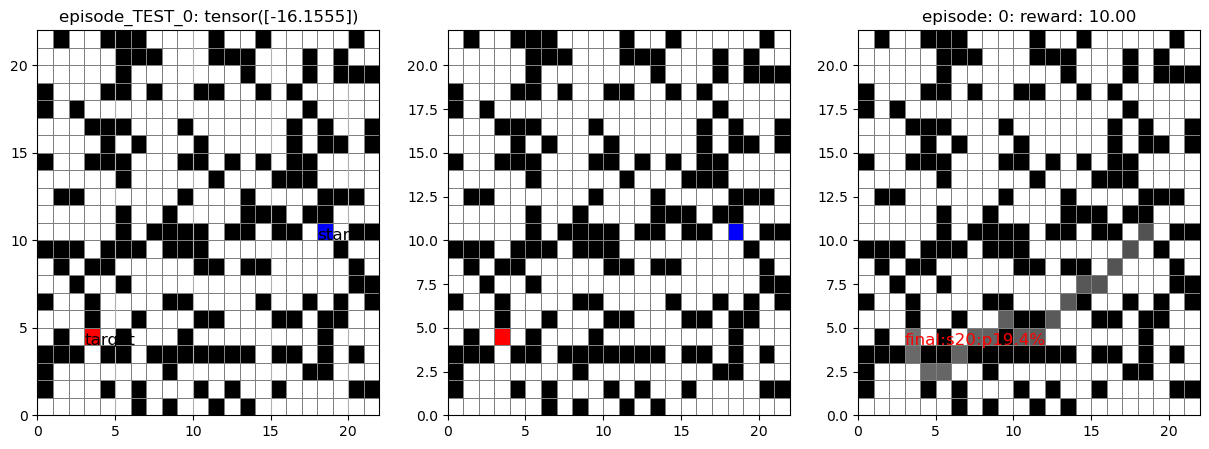

TEST:  39%|███▉      | 39/100 [00:11<00:17,  3.44it/s, split=TEST, batch_idx=19, is_episode_step_done=1, target_episodes=['episode_TEST_0', 'episode_TEST_0:clone:0', 'episode_TEST_0:clone:1', 'episode_TEST_0:clone:2', 'episode_TEST_0:clone:3', 'episode_TEST_0:clone:4', 'episode_TEST_0:clone:5', 'episode_TEST_0:clone:6', 'episode_TEST_1', 'episode_TEST_1:clone:0', 'episode_TEST_1:clone:1', 'episode_TEST_1:clone:2', 'episode_TEST_1:clone:3', 'episode_TEST_1:clone:4', 'episode_TEST_1:clone:5', 'episode_TEST_1:clone:6', 'episode_TEST_2', 'episode_TEST_2:clone:0', 'episode_TEST_2:clone:1', 'episode_TEST_2:clone:2', 'episode_TEST_2:clone:3', 'episode_TEST_2:clone:4', 'episode_TEST_2:clone:5', 'episode_TEST_2:clone:6', 'episode_TEST_3', 'episode_TEST_3:clone:0', 'episode_TEST_3:clone:1', 'episode_TEST_3:clone:2', 'episode_TEST_3:clone:3', 'episode_TEST_3:clone:4', 'episode_TEST_3:clone:5', 'episode_TEST_3:clone:6', 'episode_TEST_4', 'episode_TEST_4:clone:0', 'episode_TEST_4:clone:1', 'episode

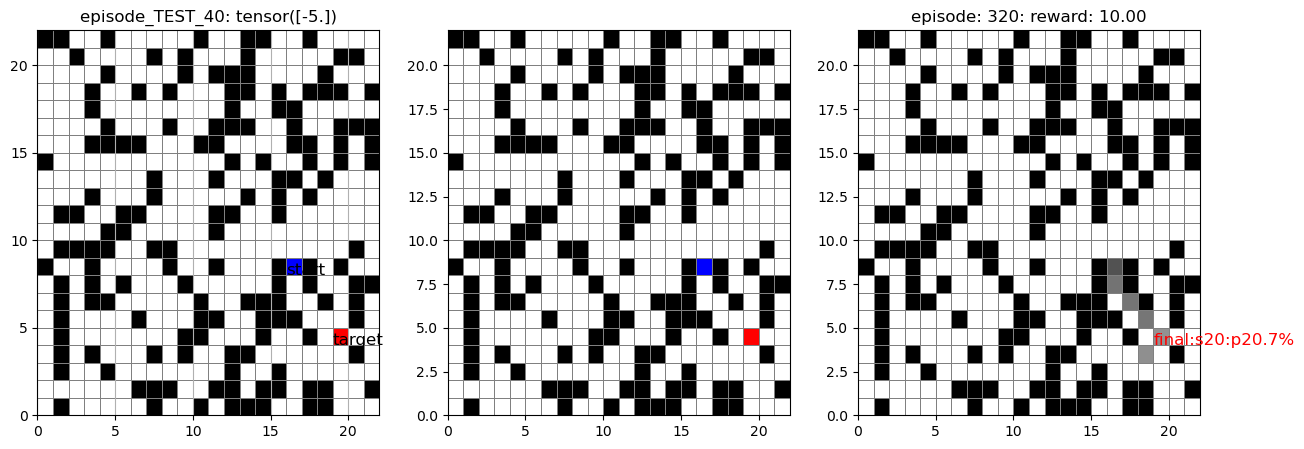

TEST:  59%|█████▉    | 59/100 [00:17<00:11,  3.51it/s, split=TEST, batch_idx=39, is_episode_step_done=1, target_episodes=['episode_TEST_40', 'episode_TEST_40:clone:0', 'episode_TEST_40:clone:1', 'episode_TEST_40:clone:2', 'episode_TEST_40:clone:3', 'episode_TEST_40:clone:4', 'episode_TEST_40:clone:5', 'episode_TEST_40:clone:6', 'episode_TEST_41', 'episode_TEST_41:clone:0', 'episode_TEST_41:clone:1', 'episode_TEST_41:clone:2', 'episode_TEST_41:clone:3', 'episode_TEST_41:clone:4', 'episode_TEST_41:clone:5', 'episode_TEST_41:clone:6', 'episode_TEST_42', 'episode_TEST_42:clone:0', 'episode_TEST_42:clone:1', 'episode_TEST_42:clone:2', 'episode_TEST_42:clone:3', 'episode_TEST_42:clone:4', 'episode_TEST_42:clone:5', 'episode_TEST_42:clone:6', 'episode_TEST_43', 'episode_TEST_43:clone:0', 'episode_TEST_43:clone:1', 'episode_TEST_43:clone:2', 'episode_TEST_43:clone:3', 'episode_TEST_43:clone:4', 'episode_TEST_43:clone:5', 'episode_TEST_43:clone:6', 'episode_TEST_44', 'episode_TEST_44:clone:0', 

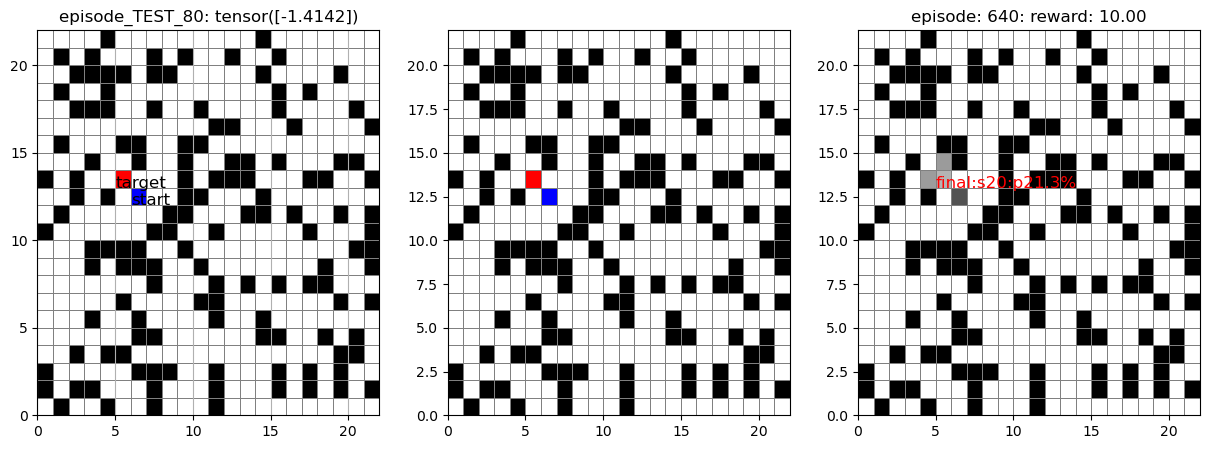

TEST:  79%|███████▉  | 79/100 [00:23<00:06,  3.42it/s, split=TEST, batch_idx=59, is_episode_step_done=1, target_episodes=['episode_TEST_80', 'episode_TEST_80:clone:0', 'episode_TEST_80:clone:1', 'episode_TEST_80:clone:2', 'episode_TEST_80:clone:3', 'episode_TEST_80:clone:4', 'episode_TEST_80:clone:5', 'episode_TEST_80:clone:6', 'episode_TEST_81', 'episode_TEST_81:clone:0', 'episode_TEST_81:clone:1', 'episode_TEST_81:clone:2', 'episode_TEST_81:clone:3', 'episode_TEST_81:clone:4', 'episode_TEST_81:clone:5', 'episode_TEST_81:clone:6', 'episode_TEST_82', 'episode_TEST_82:clone:0', 'episode_TEST_82:clone:1', 'episode_TEST_82:clone:2', 'episode_TEST_82:clone:3', 'episode_TEST_82:clone:4', 'episode_TEST_82:clone:5', 'episode_TEST_82:clone:6', 'episode_TEST_83', 'episode_TEST_83:clone:0', 'episode_TEST_83:clone:1', 'episode_TEST_83:clone:2', 'episode_TEST_83:clone:3', 'episode_TEST_83:clone:4', 'episode_TEST_83:clone:5', 'episode_TEST_83:clone:6', 'episode_TEST_84', 'episode_TEST_84:clone:0', 

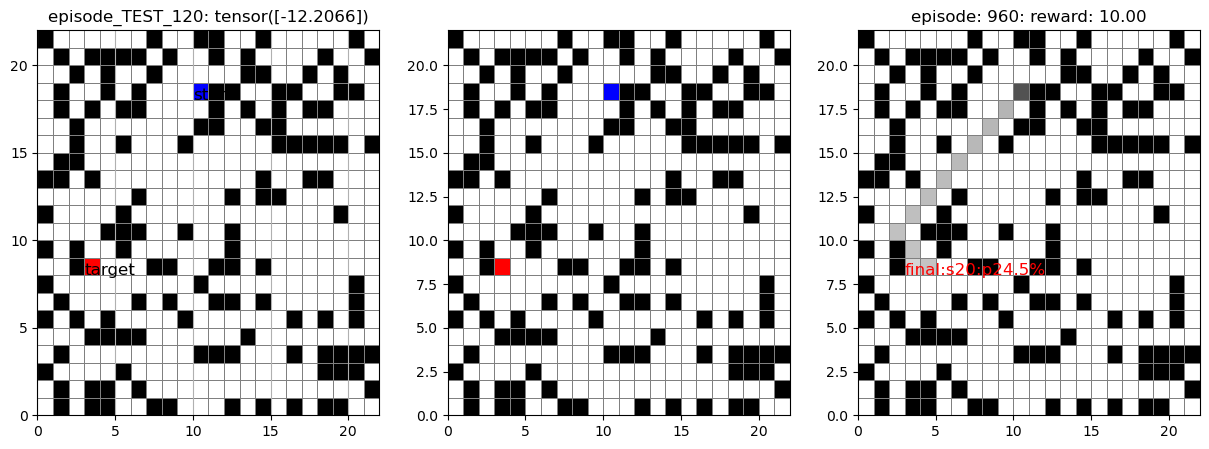

TEST:  99%|█████████▉| 99/100 [00:30<00:00,  3.33it/s, split=TEST, batch_idx=79, is_episode_step_done=1, target_episodes=['episode_TEST_120', 'episode_TEST_120:clone:0', 'episode_TEST_120:clone:1', 'episode_TEST_120:clone:2', 'episode_TEST_120:clone:3', 'episode_TEST_120:clone:4', 'episode_TEST_120:clone:5', 'episode_TEST_120:clone:6', 'episode_TEST_121', 'episode_TEST_121:clone:0', 'episode_TEST_121:clone:1', 'episode_TEST_121:clone:2', 'episode_TEST_121:clone:3', 'episode_TEST_121:clone:4', 'episode_TEST_121:clone:5', 'episode_TEST_121:clone:6', 'episode_TEST_122', 'episode_TEST_122:clone:0', 'episode_TEST_122:clone:1', 'episode_TEST_122:clone:2', 'episode_TEST_122:clone:3', 'episode_TEST_122:clone:4', 'episode_TEST_122:clone:5', 'episode_TEST_122:clone:6', 'episode_TEST_123', 'episode_TEST_123:clone:0', 'episode_TEST_123:clone:1', 'episode_TEST_123:clone:2', 'episode_TEST_123:clone:3', 'episode_TEST_123:clone:4', 'episode_TEST_123:clone:5', 'episode_TEST_123:clone:6', 'episode_TEST_

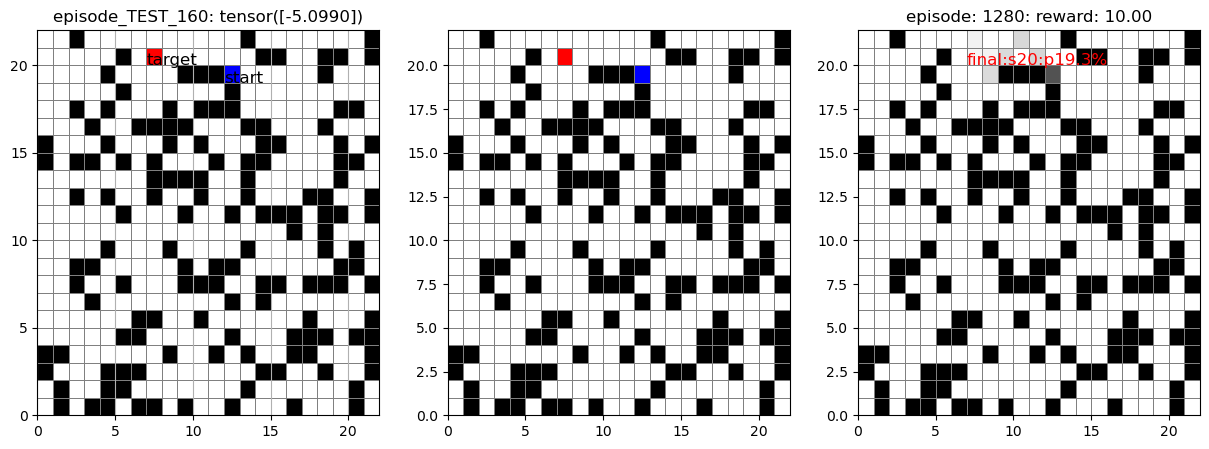

TEST: 100%|██████████| 100/100 [00:30<00:00,  3.25it/s, split=TEST, batch_idx=99, is_episode_step_done=1, target_episodes=['episode_TEST_160', 'episode_TEST_160:clone:0', 'episode_TEST_160:clone:1', 'episode_TEST_160:clone:2', 'episode_TEST_160:clone:3', 'episode_TEST_160:clone:4', 'episode_TEST_160:clone:5', 'episode_TEST_160:clone:6', 'episode_TEST_161', 'episode_TEST_161:clone:0', 'episode_TEST_161:clone:1', 'episode_TEST_161:clone:2', 'episode_TEST_161:clone:3', 'episode_TEST_161:clone:4', 'episode_TEST_161:clone:5', 'episode_TEST_161:clone:6', 'episode_TEST_162', 'episode_TEST_162:clone:0', 'episode_TEST_162:clone:1', 'episode_TEST_162:clone:2', 'episode_TEST_162:clone:3', 'episode_TEST_162:clone:4', 'episode_TEST_162:clone:5', 'episode_TEST_162:clone:6', 'episode_TEST_163', 'episode_TEST_163:clone:0', 'episode_TEST_163:clone:1', 'episode_TEST_163:clone:2', 'episode_TEST_163:clone:3', 'episode_TEST_163:clone:4', 'episode_TEST_163:clone:5', 'episode_TEST_163:clone:6', 'episode_TEST

In [28]:
# pretrain model perf

pretrain_model_path = "/Users/chengbai/ml/cheng_git/rf_agent/rf_model_policy_FINE_TUNE_STAGE_1_20250704144110_1.pt"
pre_train_policy, pre_train_optimizer, pre_train_lr_scheduler = load_checkpoint(
    checkpoint_path=pretrain_model_path,
    config=config,
    policy_mode=PolicyMode.TRANSFORMER_WITH_LATE_POSITION_FUSION,
)
pre_train_policy.to(config.device)


inference_and_plot_policy_v2(
    config=config,
    dataset=test_dataset,  # test_dataset,
    dataloader=test_dataloader,  # test_dataloader,
    policy=pre_train_policy,
    reward_model=reward_model,
    top_k=1,
)